# (Optional) Colab Setup
If you aren't using Colab, you can delete the following code cell. This is just to help students with mounting to Google Drive to access the other .py files and downloading the data, which is a little trickier on Colab than on your local machine using Jupyter. 

In [1]:
# you will be prompted with a window asking to grant permissions
# from google.colab import drive
# drive.mount("/content/drive")

In [2]:
# fill in the path in your Google Drive in the string below. Note: do not escape slashes or spaces
# import os
# datadir = "/content/assignment3"
# if not os.path.exists(datadir):
#   !ln -s "/content/drive/My Drive/Your/assignment3/path/" $datadir # TODO: Fill your assignment3 path
# os.chdir(datadir)
# !pwd

# Data Setup

The first thing to do is implement a dataset class to load rotated CIFAR10 images with matching labels. Since there is already a CIFAR10 dataset class implemented in `torchvision`, we will extend this class and modify the `__get_item__` method appropriately to load rotated images.

Each rotation label should be an integer in the set {0, 1, 2, 3} which correspond to rotations of 0, 90, 180, or 270 degrees respectively.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random



In [2]:
# This is in an external file
import os

if os.path.exists('dataset.py'):
    from dataset import *
else:
    def rotate_img(img, rot: int):
        if rot == 0: # 0 degrees rotation
            return img
        # TODO: Implement rotate_img() - return the rotated img
        elif rot == 1:  # 90 degrees rotation
            return torch.rot90(img, k=1, dims=[1, 2])
        elif rot == 2:  # 180 degrees rotation
            return torch.rot90(img, k=2, dims=[1, 2])
        elif rot == 3:  # 270 degrees rotation
            return torch.rot90(img, k=3, dims=[1, 2])
        else:
            raise ValueError('rotation should be 0, 90, 180, or 270 degrees')


    class CIFAR10Rotation(torchvision.datasets.CIFAR10):

        def __init__(self, root, train, download, transform) -> None:
            super().__init__(root=root, train=train, download=download, transform=transform)
        
        def __len__(self):
            return len(self.data)
        
        def __getitem__(self, index: int):
            image, cls_label = super().__getitem__(index)

            # randomly select image rotation
            rotation_label = random.choice([0, 1, 2, 3])
            image_rotated = rotate_img(image, rotation_label)

            rotation_label = torch.tensor(rotation_label).long()
            return image, image_rotated, rotation_label, torch.tensor(cls_label).long()


    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    batch_size = 128

    trainset = CIFAR10Rotation(root='./data', train=True,
                                            download=True, transform=transform_train)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                              shuffle=True, num_workers=0)

    testset = CIFAR10Rotation(root='./data', train=False,
                                           download=True, transform=transform_test)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                             shuffle=False, num_workers=0)

Files already downloaded and verified
Files already downloaded and verified


Show some example images and rotated images with labels:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


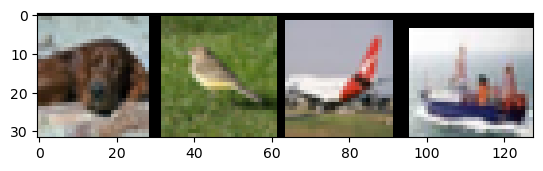

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Class labels:  dog   bird  plane ship 


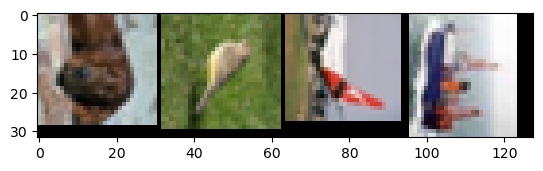

Rotation labels:  270   270   270   270  


In [3]:

import matplotlib.pyplot as plt

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

rot_classes = ('0', '90', '180', '270')


def imshow(img):
    # unnormalize
    img = transforms.Normalize((0, 0, 0), (1/0.2023, 1/0.1994, 1/0.2010))(img)
    img = transforms.Normalize((-0.4914, -0.4822, -0.4465), (1, 1, 1))(img)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(trainloader)
images, rot_images, rot_labels, labels = next(dataiter)

# print images and rotated images
img_grid = imshow(torchvision.utils.make_grid(images[:4], padding=0))
print('Class labels: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))
img_grid = imshow(torchvision.utils.make_grid(rot_images[:4], padding=0))
print('Rotation labels: ', ' '.join(f'{rot_classes[rot_labels[j]]:5s}' for j in range(4)))

# Evaluation code

In [4]:
import time

def run_test(net, testloader, criterion, task):
    correct = 0
    total = 0
    avg_test_loss = 0.0
    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for images, images_rotated, labels, cls_labels in testloader:
            if task == 'rotation':
              images, labels = images_rotated.to(device), labels.to(device)
            elif task == 'classification':
              images, labels = images.to(device), cls_labels.to(device)
            # TODO: Calculate outputs by running images through the network
            # The class with the highest energy is what we choose as prediction
            
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # loss
            avg_test_loss += criterion(outputs, labels)  / len(testloader)
    print('TESTING:')
    print(f'Accuracy of the network on the 10000 test images: {100 * correct / total:.2f} %')
    print(f'Average loss on the 10000 test images: {avg_test_loss:.3f}')

In [5]:
def adjust_learning_rate(optimizer, epoch, init_lr, decay_epochs=30):
    """Sets the learning rate to the initial LR decayed by 10 every 30 epochs"""
    lr = init_lr * (0.1 ** (epoch // decay_epochs))
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

## 1. Train a ResNet18 on the rotation task

In this section, we will train a ResNet18 model on the rotation task. The input is a rotated image and the model predicts the rotation label. See the Data Setup section for details.

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

In [7]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

net = resnet18(num_classes=4)
net = net.to(device)

In [8]:
import torch.optim as optim

# TODO: Define criterion and optimizer

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4) 
# optimizer = optim.Adam(net.parameters(), lr=0.001)

In [9]:
# Both the self-supervised rotation task and supervised CIFAR10 classification are
# trained with the CrossEntropyLoss, so we can use the training loop code.

def train(net, criterion, optimizer, num_epochs, decay_epochs, init_lr, task):

    for epoch in range(num_epochs):  # loop over the dataset multiple times

        running_loss = 0.0
        running_correct = 0.0
        running_total = 0.0
        start_time = time.time()
        epoch_start_time = time.time()

        net.to(device)

        net.train()

        for i, (imgs, imgs_rotated, rotation_label, cls_label) in enumerate(trainloader, 0):
            adjust_learning_rate(optimizer, epoch, init_lr, decay_epochs)

            # TODO: Set the data to the correct device; Different task will use different inputs and labels
            #
            if task == 'rotation':
                images, labels = imgs_rotated.to(device), rotation_label.to(device)
            elif task == 'classification':
                images, labels = imgs.to(device), cls_label.to(device)

            # TODO: Zero the parameter gradients
            #
            optimizer.zero_grad()

            # TODO: forward + backward + optimize
            #
            outputs = net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # TODO: Get predicted results
            predicted = torch.max(outputs.data, 1)[1]

            # print statistics
            print_freq = 100
            running_loss += loss.item()

            # calc acc
            running_total += labels.size(0)
            running_correct += (predicted == labels).sum().item()

            if i % print_freq == (print_freq - 1):    # print every 2000 mini-batches
                print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / print_freq:.3f} acc: {100*running_correct / running_total:.2f} time: {time.time() - start_time:.2f}')
                running_loss, running_correct, running_total = 0.0, 0.0, 0.0
                start_time = time.time()

        # TODO: Run the run_test() function after each epoch; Set the model to the evaluation mode.
        net.eval()
        run_test(net, testloader, criterion, task)
        print('Time taken for epoch %d: %.2f' % (epoch + 1, time.time() - epoch_start_time))
    print('Finished Training')


In [12]:
train(net, criterion, optimizer, num_epochs=45, decay_epochs=15, init_lr=0.01, task='rotation')

# TODO: Save the model
MODEL_PATH = './rotation_model.pth'
torch.save(net.state_dict(), MODEL_PATH)

[1,   100] loss: 1.385 acc: 38.40 time: 3.57
[1,   200] loss: 1.183 acc: 47.67 time: 2.94
[1,   300] loss: 1.137 acc: 50.19 time: 2.86
TESTING:
Accuracy of the network on the 10000 test images: 55.46 %
Average loss on the 10000 test images: 1.052
Time taken for epoch 1: 14.00
[2,   100] loss: 1.087 acc: 53.61 time: 3.42
[2,   200] loss: 1.084 acc: 53.61 time: 2.71
[2,   300] loss: 1.060 acc: 54.79 time: 2.72
TESTING:
Accuracy of the network on the 10000 test images: 57.37 %
Average loss on the 10000 test images: 1.001
Time taken for epoch 2: 13.29
[3,   100] loss: 1.035 acc: 56.27 time: 3.44
[3,   200] loss: 1.010 acc: 57.40 time: 2.72
[3,   300] loss: 1.004 acc: 57.65 time: 2.69
TESTING:
Accuracy of the network on the 10000 test images: 60.27 %
Average loss on the 10000 test images: 0.955
Time taken for epoch 3: 13.35
[4,   100] loss: 0.982 acc: 58.77 time: 3.61
[4,   200] loss: 0.973 acc: 59.56 time: 2.76
[4,   300] loss: 0.954 acc: 60.11 time: 2.66
TESTING:
Accuracy of the network o

## 2.1 Fine-tuning on the pre-trained model

In this section, we will load the pre-trained ResNet18 model and fine-tune on the classification task. We will freeze all previous layers except for the 'layer4' block and 'fc' layer.

In [7]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

# TODO: Load the pre-trained ResNet18 model
MODEL_PATH = './rotation_model.pth'

net = resnet18(num_classes=4)
net = net.to(device)
net.load_state_dict(torch.load(MODEL_PATH))


# HERE
# Not sure if this is needed. IT IS NEEDED
num_ftrs = net.fc.in_features
net.fc = nn.Linear(num_ftrs, len(classes))
net = net.to(device)


In [14]:
# TODO: Freeze all previous layers; only keep the 'layer4' block and 'fc' layer trainable
for param in net.parameters():
    param.requires_grad = False
for param in net.layer4.parameters():
    param.requires_grad = True
for param in net.fc.parameters():
    param.requires_grad = True


In [15]:
# Print all the trainable parameters
params_to_update = net.parameters()
print("Params to learn:")
params_to_update = []
for name,param in net.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print("\t",name)

Params to learn:
	 layer4.0.conv1.weight
	 layer4.0.bn1.weight
	 layer4.0.bn1.bias
	 layer4.0.conv2.weight
	 layer4.0.bn2.weight
	 layer4.0.bn2.bias
	 layer4.0.downsample.0.weight
	 layer4.0.downsample.1.weight
	 layer4.0.downsample.1.bias
	 layer4.1.conv1.weight
	 layer4.1.bn1.weight
	 layer4.1.bn1.bias
	 layer4.1.conv2.weight
	 layer4.1.bn2.weight
	 layer4.1.bn2.bias
	 fc.weight
	 fc.bias


In [16]:
# TODO: Define criterion and optimizer
# Note that your optimizer only needs to update the parameters that are trainable.
criterion = nn.CrossEntropyLoss() 
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

In [17]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=0.01, task='classification')

# Save the model
MODEL_PATH = './classification_model-2-1.pth'


[1,   100] loss: 1.608 acc: 41.97 time: 3.22
[1,   200] loss: 1.398 acc: 49.21 time: 2.66
[1,   300] loss: 1.324 acc: 51.84 time: 2.61
TESTING:
Accuracy of the network on the 10000 test images: 54.37 %
Average loss on the 10000 test images: 1.255
Time taken for epoch 1: 13.02
[2,   100] loss: 1.269 acc: 54.25 time: 3.31
[2,   200] loss: 1.259 acc: 54.23 time: 2.67
[2,   300] loss: 1.236 acc: 54.82 time: 2.58
TESTING:
Accuracy of the network on the 10000 test images: 57.04 %
Average loss on the 10000 test images: 1.183
Time taken for epoch 2: 12.90
[3,   100] loss: 1.191 acc: 56.65 time: 3.21
[3,   200] loss: 1.210 acc: 56.40 time: 2.54
[3,   300] loss: 1.195 acc: 57.34 time: 2.55
TESTING:
Accuracy of the network on the 10000 test images: 58.12 %
Average loss on the 10000 test images: 1.165
Time taken for epoch 3: 12.78
[4,   100] loss: 1.166 acc: 57.78 time: 3.12
[4,   200] loss: 1.157 acc: 58.77 time: 2.51
[4,   300] loss: 1.161 acc: 57.93 time: 2.54
TESTING:
Accuracy of the network o

## 2.2 Fine-tuning on the randomly initialized model
In this section, we will randomly initialize a ResNet18 model and fine-tune on the classification task. We will freeze all previous layers except for the 'layer4' block and 'fc' layer.

In [19]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Randomly initialize a ResNet18 model

net = resnet18(num_classes=len(classes))
net = net.to(device)
device

'cuda'

In [20]:
# TODO: Freeze all previous layers; only keep the 'layer4' block and 'fc' layer trainable
# To do this, you should set requires_grad=False for the frozen layers.

for param in net.parameters():
    param.requires_grad = False
for param in net.layer4.parameters():
    param.requires_grad = True
for param in net.fc.parameters():
    param.requires_grad = True


In [21]:
# Print all the trainable parameters
params_to_update = net.parameters()
print("Params to learn:")
params_to_update = []
for name,param in net.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print("\t",name)

Params to learn:
	 layer4.0.conv1.weight
	 layer4.0.bn1.weight
	 layer4.0.bn1.bias
	 layer4.0.conv2.weight
	 layer4.0.bn2.weight
	 layer4.0.bn2.bias
	 layer4.0.downsample.0.weight
	 layer4.0.downsample.1.weight
	 layer4.0.downsample.1.bias
	 layer4.1.conv1.weight
	 layer4.1.bn1.weight
	 layer4.1.bn1.bias
	 layer4.1.conv2.weight
	 layer4.1.bn2.weight
	 layer4.1.bn2.bias
	 fc.weight
	 fc.bias


In [22]:
import torch.optim as optim

# TODO: Define criterion and optimizer
# Note that your optimizer only needs to update the parameters that are trainable.
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(params_to_update, lr=0.01, momentum=0.9)

In [23]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=0.01, task='classification')

# Save the model
MODEL_PATH = './classification_model-2-2.pth'
torch.save(net.state_dict(), MODEL_PATH)

[1,   100] loss: 2.134 acc: 23.91 time: 2.80
[1,   200] loss: 1.985 acc: 28.54 time: 2.22
[1,   300] loss: 1.931 acc: 30.14 time: 2.23
TESTING:
Accuracy of the network on the 10000 test images: 34.67 %
Average loss on the 10000 test images: 1.809
Time taken for epoch 1: 11.19
[2,   100] loss: 1.881 acc: 32.05 time: 2.90
[2,   200] loss: 1.848 acc: 33.56 time: 2.33
[2,   300] loss: 1.837 acc: 34.08 time: 2.24
TESTING:
Accuracy of the network on the 10000 test images: 35.55 %
Average loss on the 10000 test images: 1.760
Time taken for epoch 2: 11.50
[3,   100] loss: 1.818 acc: 34.03 time: 2.92
[3,   200] loss: 1.810 acc: 34.18 time: 2.26
[3,   300] loss: 1.797 acc: 35.05 time: 2.30
TESTING:
Accuracy of the network on the 10000 test images: 39.68 %
Average loss on the 10000 test images: 1.690
Time taken for epoch 3: 11.58
[4,   100] loss: 1.767 acc: 35.94 time: 2.85
[4,   200] loss: 1.765 acc: 35.73 time: 2.30
[4,   300] loss: 1.759 acc: 36.45 time: 2.26
TESTING:
Accuracy of the network o

## 3.1 Supervised training on the pre-trained model
In this section, we will load the pre-trained ResNet18 model and re-train the whole model on the classification task.

In [10]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Load the pre-trained ResNet18 model

MODEL_PATH = './rotation_model.pth'
net = resnet18(num_classes=4)
net = net.to(device)
state_dict = torch.load(MODEL_PATH)
net.load_state_dict(state_dict)

num_ftrs = net.fc.in_features
net.fc = nn.Linear(num_ftrs, len(classes))

/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [11]:
import torch.optim as optim


# TODO: Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)

In [12]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=0.01, task='classification')

# Save the model
MODEL_PATH = './classification_model-3-1.pth'
torch.save(net.state_dict(), MODEL_PATH)

[1,   100] loss: 1.531 acc: 44.98 time: 2.97
[1,   200] loss: 1.236 acc: 55.39 time: 2.36
[1,   300] loss: 1.151 acc: 58.82 time: 2.31
TESTING:
Accuracy of the network on the 10000 test images: 62.89 %
Average loss on the 10000 test images: 1.050
Time taken for epoch 1: 11.68
[2,   100] loss: 1.044 acc: 63.16 time: 2.81
[2,   200] loss: 0.986 acc: 64.43 time: 2.30
[2,   300] loss: 0.987 acc: 64.50 time: 2.34
TESTING:
Accuracy of the network on the 10000 test images: 65.75 %
Average loss on the 10000 test images: 0.988
Time taken for epoch 2: 11.38
[3,   100] loss: 0.923 acc: 67.55 time: 3.01
[3,   200] loss: 0.902 acc: 68.44 time: 2.40
[3,   300] loss: 0.891 acc: 68.68 time: 2.39
TESTING:
Accuracy of the network on the 10000 test images: 69.74 %
Average loss on the 10000 test images: 0.874
Time taken for epoch 3: 11.86
[4,   100] loss: 0.842 acc: 70.00 time: 2.94
[4,   200] loss: 0.828 acc: 71.16 time: 2.40
[4,   300] loss: 0.813 acc: 71.39 time: 2.36
TESTING:
Accuracy of the network o

## 3.2 Supervised training on the randomly initialized model
In this section, we will randomly initialize a ResNet18 model and re-train the whole model on the classification task.

In [13]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Randomly initialize a ResNet18 model
net = resnet18(num_classes=len(classes)).to(device)
device

'cuda'

In [14]:
# TODO: Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)

In [15]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=0.01, task='classification')

# Save the model
MODEL_PATH = './classification_model-3-2.pth'

[1,   100] loss: 1.993 acc: 28.71 time: 2.98
[1,   200] loss: 1.650 acc: 39.88 time: 2.36
[1,   300] loss: 1.583 acc: 42.65 time: 2.35
TESTING:
Accuracy of the network on the 10000 test images: 50.30 %
Average loss on the 10000 test images: 1.367
Time taken for epoch 1: 11.74
[2,   100] loss: 1.440 acc: 48.12 time: 2.94
[2,   200] loss: 1.372 acc: 50.95 time: 2.39
[2,   300] loss: 1.313 acc: 52.57 time: 2.38
TESTING:
Accuracy of the network on the 10000 test images: 57.16 %
Average loss on the 10000 test images: 1.183
Time taken for epoch 2: 11.84
[3,   100] loss: 1.215 acc: 56.22 time: 2.90
[3,   200] loss: 1.172 acc: 58.13 time: 2.39
[3,   300] loss: 1.134 acc: 59.43 time: 2.37
TESTING:
Accuracy of the network on the 10000 test images: 62.86 %
Average loss on the 10000 test images: 1.052
Time taken for epoch 3: 11.57
[4,   100] loss: 1.073 acc: 61.81 time: 2.90
[4,   200] loss: 1.074 acc: 61.98 time: 2.39
[4,   300] loss: 1.033 acc: 63.01 time: 2.40
TESTING:
Accuracy of the network o

# Section 4
 
Change the architecture to a ResNet50

In [14]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

from torchvision.models import resnet50

net = resnet50(num_classes=4)
net = net.to(device)

In [15]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4) 
# optimizer = optim.Adam(net.parameters(), lr=0.001, weight_decay=5e-4)

In [16]:
train(net, criterion, optimizer, num_epochs=135, decay_epochs=100, init_lr=0.01, task='rotation')

MODEL_PATH = './rotation_model_resnet50.pth'
torch.save(net.state_dict(), MODEL_PATH)


[1,   100] loss: 2.855 acc: 27.48 time: 3.40
[1,   200] loss: 2.317 acc: 31.80 time: 2.82
[1,   300] loss: 2.313 acc: 33.66 time: 2.86
TESTING:
Accuracy of the network on the 10000 test images: 39.43 %
Average loss on the 10000 test images: 1.451
Time taken for epoch 1: 13.67
[2,   100] loss: 1.841 acc: 37.40 time: 3.60
[2,   200] loss: 1.910 acc: 38.90 time: 2.91
[2,   300] loss: 1.875 acc: 36.76 time: 2.88
TESTING:
Accuracy of the network on the 10000 test images: 27.41 %
Average loss on the 10000 test images: 1.439
Time taken for epoch 2: 13.99
[3,   100] loss: 1.691 acc: 35.09 time: 3.43
[3,   200] loss: 1.831 acc: 33.07 time: 2.86
[3,   300] loss: 1.576 acc: 33.50 time: 2.88
TESTING:
Accuracy of the network on the 10000 test images: 40.51 %
Average loss on the 10000 test images: 1.376
Time taken for epoch 3: 13.87
[4,   100] loss: 1.633 acc: 37.02 time: 3.53
[4,   200] loss: 1.640 acc: 38.44 time: 2.90
[4,   300] loss: 1.513 acc: 39.40 time: 2.90
TESTING:
Accuracy of the network o

From this: rotation_model_resnet50, train the full network on the supervised CIFAR10 classification task.

From random weights, train the full network on the supervised CIFAR10 classification task

In [17]:
!!curl \
  -d "UIUC all done 😀" \
  ntfy.sh/availableAstrak

['  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current',
 '                                 Dload  Upload   Total   Spent    Left  Speed',
 '',
 '  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0',
 '100   154  100   136  100    18   1117    147 --:--:-- --:--:-- --:--:--  1272',
 '{"id":"AS5cY0c6Jn3H","time":1743246132,"expires":1743289332,"event":"message","topic":"availableAstrak","message":"UIUC all done 😀"}']

## 4 3.1 

In [22]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet50

MODEL_PATH = './rotation_model_resnet50.pth'
net = resnet50(num_classes=4)
net = net.to(device)
state_dict = torch.load(MODEL_PATH)
net.load_state_dict(state_dict)

num_ftrs = net.fc.in_features
net.fc = nn.Linear(num_ftrs, len(classes))

In [23]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)

In [24]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=0.01, task='classification')

# Save the model
MODEL_PATH = './classification_model-4-3-1.pth'
torch.save(net.state_dict(), MODEL_PATH)

[1,   100] loss: 1.323 acc: 53.95 time: 3.34
[1,   200] loss: 1.009 acc: 65.29 time: 2.87
[1,   300] loss: 0.929 acc: 68.48 time: 2.87
TESTING:
Accuracy of the network on the 10000 test images: 72.87 %
Average loss on the 10000 test images: 0.799
Time taken for epoch 1: 13.79
[2,   100] loss: 0.806 acc: 72.19 time: 3.41
[2,   200] loss: 0.796 acc: 72.51 time: 2.88
[2,   300] loss: 0.766 acc: 73.97 time: 2.80
TESTING:
Accuracy of the network on the 10000 test images: 74.61 %
Average loss on the 10000 test images: 0.738
Time taken for epoch 2: 13.69
[3,   100] loss: 0.704 acc: 75.62 time: 3.60
[3,   200] loss: 0.696 acc: 76.02 time: 2.82
[3,   300] loss: 0.705 acc: 76.05 time: 2.81
TESTING:
Accuracy of the network on the 10000 test images: 75.59 %
Average loss on the 10000 test images: 0.699
Time taken for epoch 3: 13.93
[4,   100] loss: 0.634 acc: 78.18 time: 3.61
[4,   200] loss: 0.654 acc: 77.14 time: 2.88
[4,   300] loss: 0.635 acc: 78.02 time: 2.90
TESTING:
Accuracy of the network o

In [ ]:
!curl \
  -d "UIUC done clasification 4.3.1 model" \
  ntfy.sh/availableAstrak